# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### Откройте файл с данными и изучите общую информацию

Импортируем библиотеку pandas. Считаем данные из csv-файла в датафрейм и сохраните в переменную `data`.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

try:
    data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')

Выведем первые 20 строчек датафрейма `data` на экран.

In [6]:
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


Выведем основную информацию о датафрейме с помощью метода `info()`.

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Построим гистограмму для всех числовых столбцов таблицы

Сразу переименуем столбец `cityCenters_nearest`

In [11]:
data.rename(columns={'cityCenters_nearest': 'city_centers_nearest'}, inplace=True)

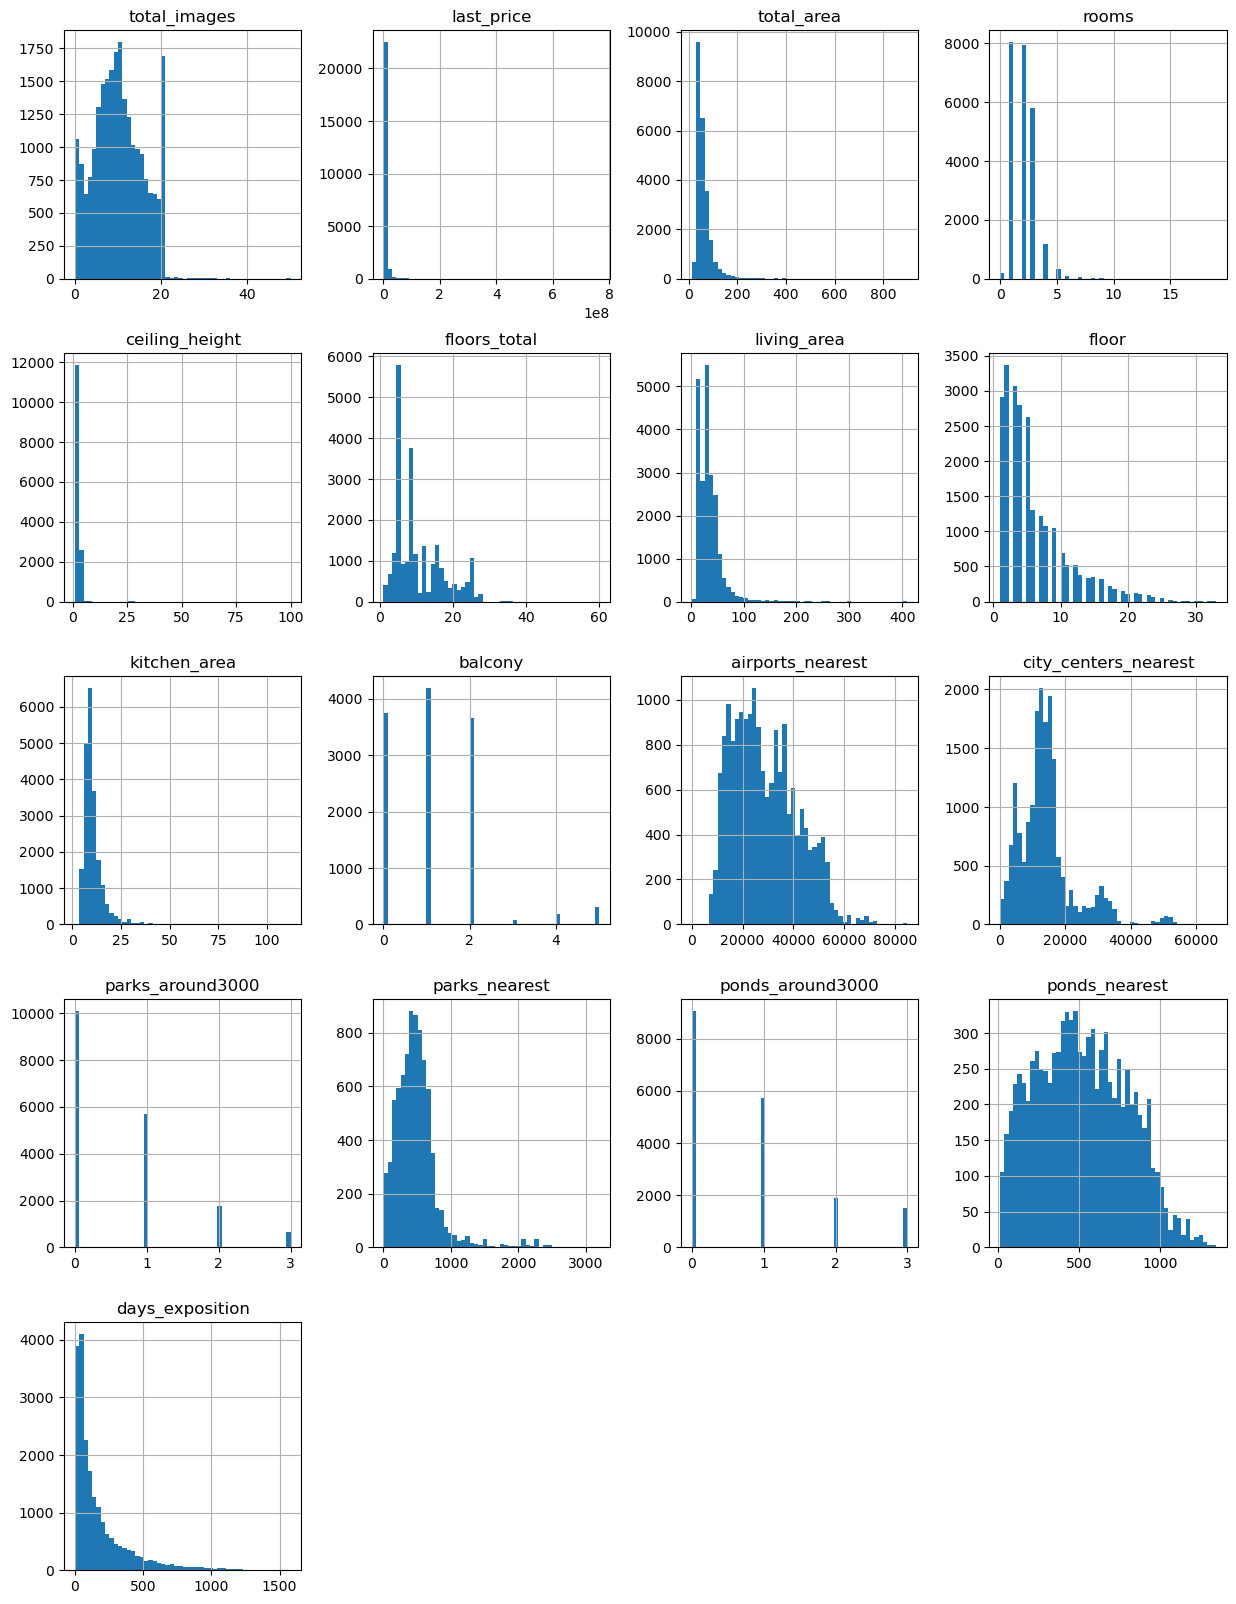

In [12]:
data.hist(figsize=(15, 20), bins=50)
plt.show()

**По гистограммам мы видим явно ошибочные значения в столбце `ceiling_height`. Так же в данных имеются пропуски, выполним предобработку.**

### Выполните предобработку данных

#### Удаление пропусков

Выведем количество пропущенных значений для каждого столбца.

<Axes: >

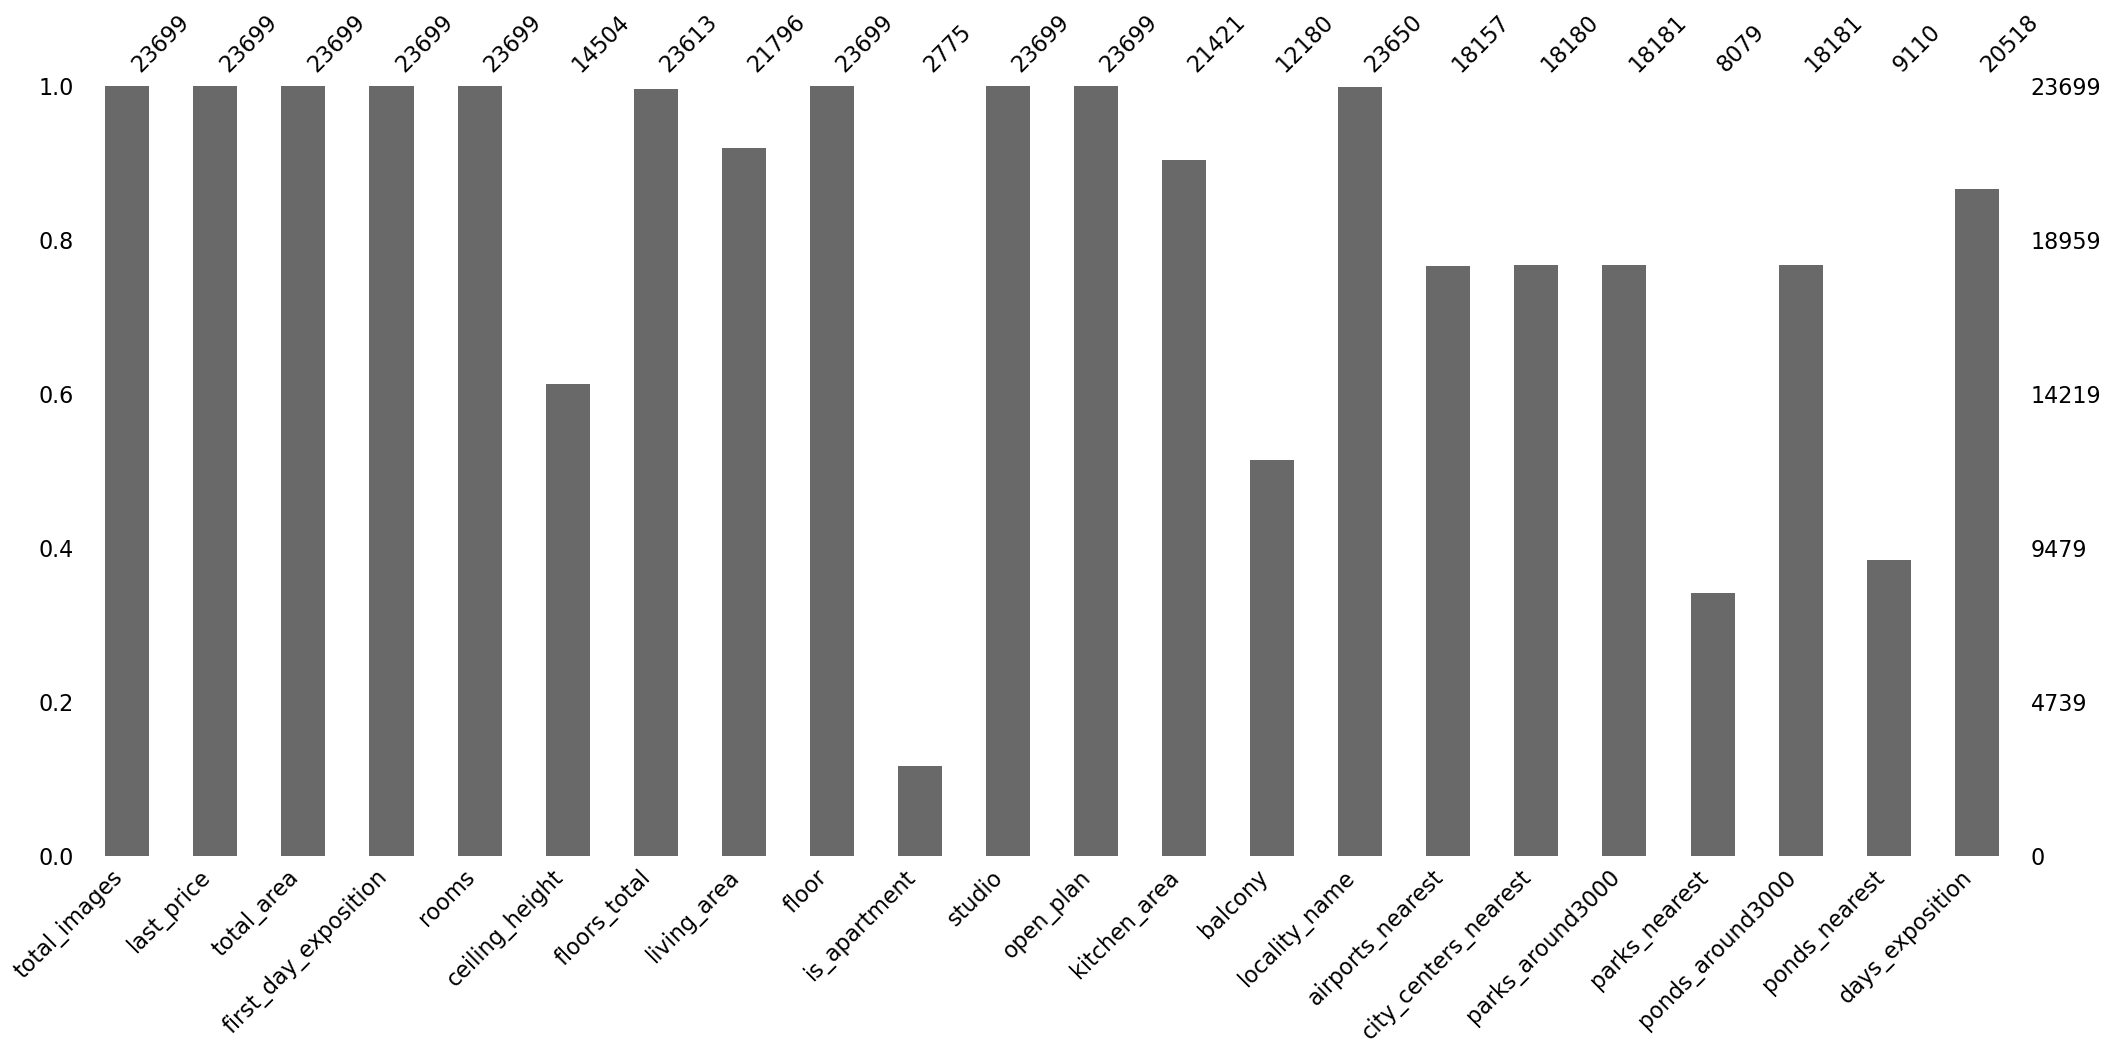

In [17]:
msno.bar(data)

Пропуски в столбце `ceiling_height` вероятнее всего образовались из-за ошибок заполнения, либо из-за ошибки при выгрузке данных. Пропущенных значений слишком много, чтобы считать намеренным сокрытием для искажения информации в объявлении. Логичную замену предложить не считаю возможным, поэтому оставим пропуски как есть.

Пропуски в столбце `floors_total`вероятнее всего образовались из-за сознательного пропуска при заполнении людей, проживающих на первых или последних этажах. Присвоим пропускам значения столбца `floor` 

In [20]:
data['floors_total'] = data['floors_total'].fillna(data['floor'])

Пропуски в столбцах `living_area` и `kitchen_area` вероятнее всего образовались из-за ошибок при заполнении. Присвоим пропускам среднее значение жилой площади квартир с такой же общей площадью.

Сначала объявим функцию для заполнения пропусков в датафрейме. Параметрами функции будут датафрейм `df`, столбец, по уникальным значениям которого будет определяться выборка для заполнения пропусков `a`, столбец, в котором необходимо заполнить пропуски `b`.

In [23]:
def fil_gaps(df, a, b=[]):
    for i in b:
        for t in df[a].unique():
            df.loc[(data[a] == t) & (df[i].isna()), i] = \
            df.loc[(data[a] == t), i].median()

In [24]:
pd.options.mode.chained_assignment = None

In [25]:
fil_gaps(data, 'total_area', ['living_area', 'kitchen_area'])

Как видим, данная функция не может заполнить все пропуски, так как для некоторых значений площади в столбцах `living_area` и `kitchen_area` только пустые значения. Логично заполнить оставшиеся пропуски не вижу возможности.

В столбце `is_apartment` очень много пропущенных значений. И соотношение `True` / `False` является очень нетипичным для рынка недвижимости. Скорее всего это какая-то техническая ошибка. Данный столбец неинформативен, поэтому целесообразно его удалить

In [28]:
data['is_apartment'].value_counts()

is_apartment
False    2725
True       50
Name: count, dtype: int64

In [29]:
data.drop('is_apartment', axis=1, inplace=True)

Если продавец не указал число балконов, то, скорее всего, в его квартире их нет. Такие пропуски можно заменить на число 0

In [31]:
data['balcony'] = data['balcony'].fillna(0)

Пропуски в столбце `locality_name` могут быть обусловлены сознательными, например, чтобы привлечь внимание покупателей, либо ошибкой при заполнении или выгрузке. Таких пропусков всего 49, поэтому ими можно пренебречь

In [33]:
data = data.dropna(subset=['locality_name'])

Пропуски в столбце `days_exposition` могут быть обусловлены тем, что квартира не была продана, либо ошибками при заполнении/выгрузке. Логичную замену предложить не вижу возможности, а удалять более 3 тысяч строк при выборке в 23 тысячи считаю нецелесообразным, поэтому оставим пропуски как есть.
Для обработки пропусков в оставшихся столбцах нелбходимо обработать дубликаты в столбце `locality_name`.

#### Обработка дубликатов

In [36]:
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

In [37]:
data['locality_name'].nunique()

364

Заменим "ё" на "е" и исправим дубликаты типа 'посёлок Мурино' и 'Мурино'

In [39]:
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё', 'е')
    .replace(['поселок ', 'городской поселок ', 'поселок городского типа ', 'деревня ', 'садовое товарищество ',
              'городского типа ', 'коттеджный ', 'городской ', 'станции ', 'городской ', 'при железнодорожной ',
             'село ', 'садоводческое некоммерческое товарищество ', 'имени '], '', regex=True)
) 

In [40]:
data['locality_name'].nunique()

305

Как видно, количество уникальных объектов, а, соответственно и количество дубликатов снизилось. Проверим данные на наличие явных дубликатов.

In [42]:
data.duplicated().sum()

0

Явных дубликатов нет.

#### Удаление пропусков (продолжение)

Заменим пропуски в столбцах `airports_nearest`, `city_centers_nearest`, `parks_around3000`, `parks_nearest`, `ponds_around3000`, `ponds_nearest`.

In [46]:
fil_gaps(data, 'locality_name', ['airports_nearest', 'city_centers_nearest', 'parks_around3000', 'parks_nearest', 'ponds_around3000', 'ponds_nearest'])

Как видим, многие пропуски остались не заполнены. Это связано с тем, что в некоторых населенных пунктах данные столбцы не заполнены вовсе из-за возможно большой удаленности аэропорта, отсутсвия поблизости парков и водоемов и т.д. Так же возможна напрвильная работа алгоритмов автозаполнения. Заполним оставшиеся пропуски в столбцах `parks_around3000` и `ponds_around3000` нулями. Способы логично заполнить остальные пропуски не вижу, оставим их как есть.

In [48]:
data['parks_around3000'] = data['parks_around3000'].fillna(0)
data['ponds_around3000'] = data['ponds_around3000'].fillna(0)

<Axes: >

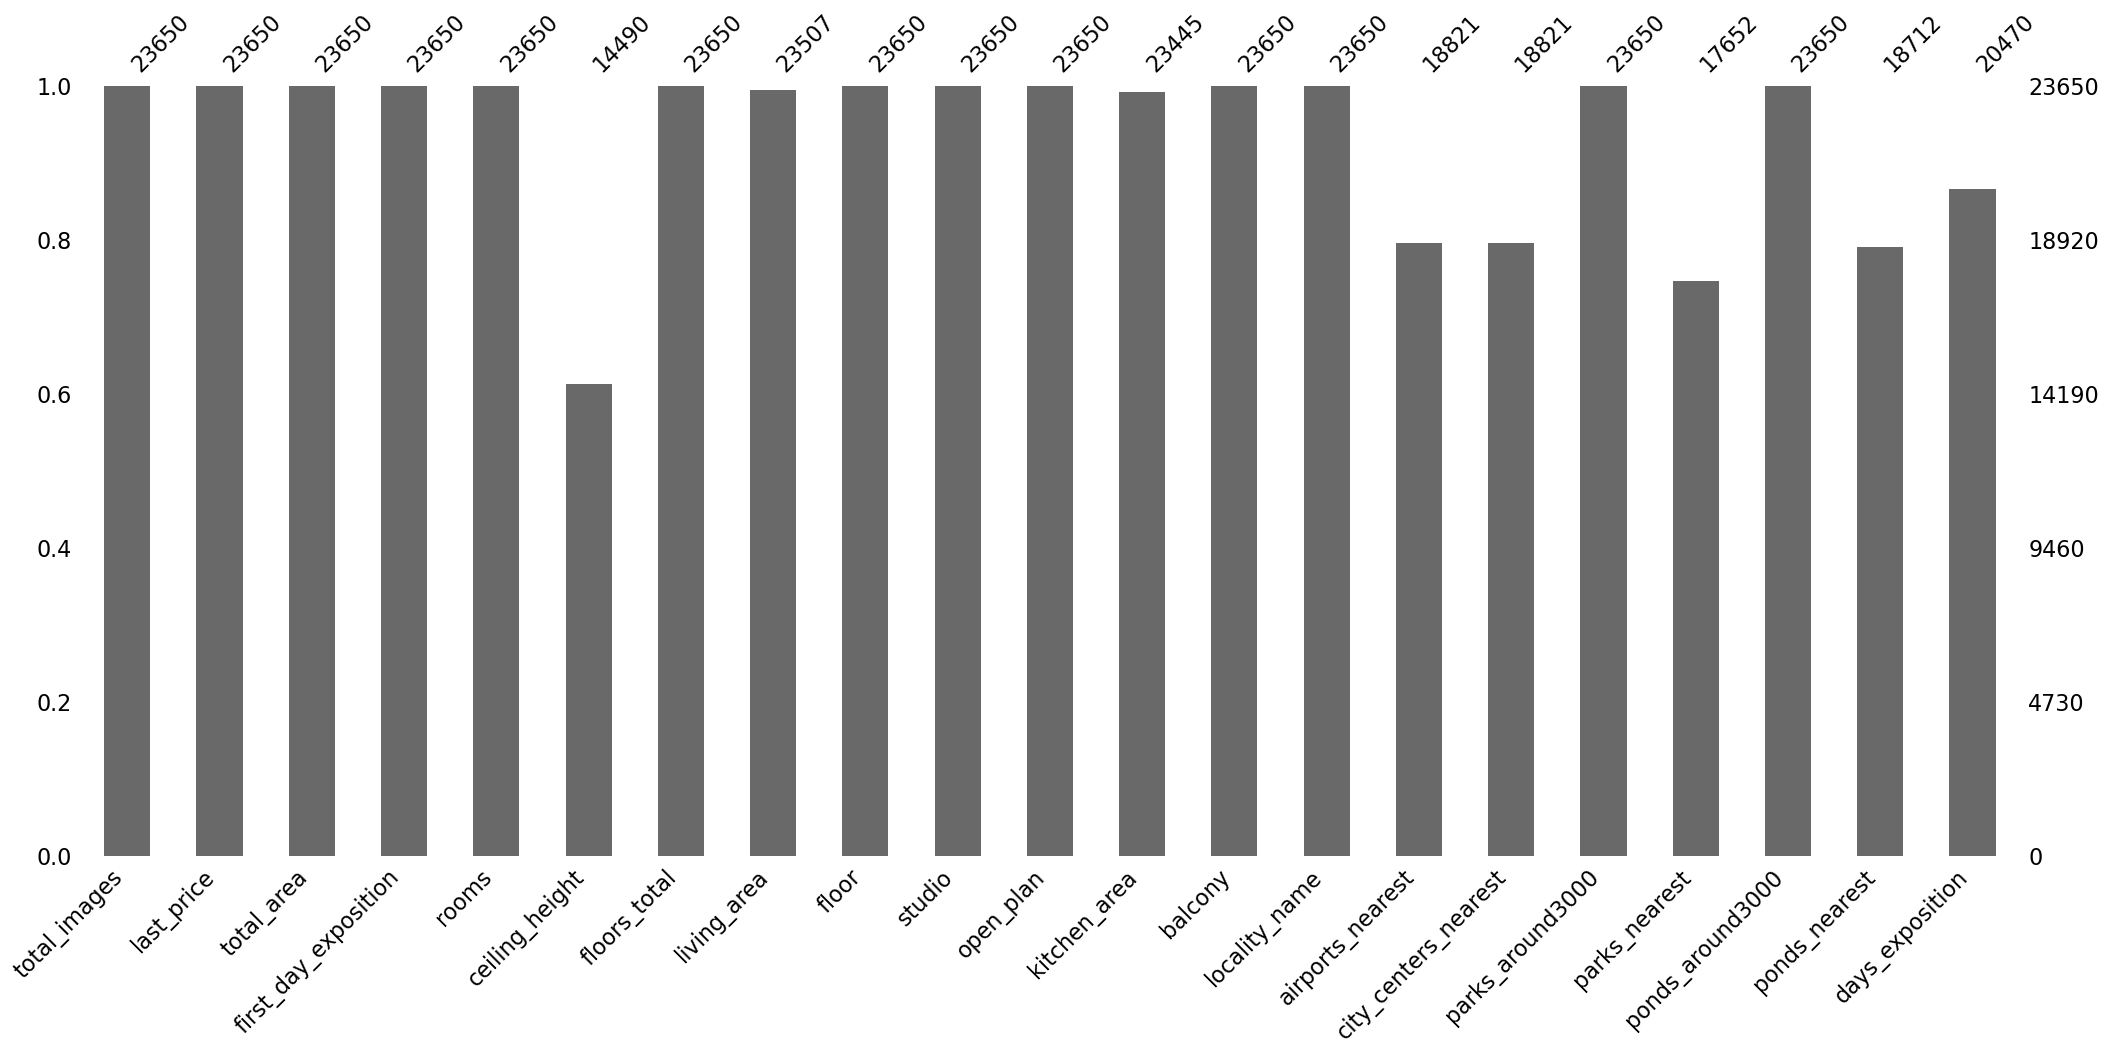

In [49]:
msno.bar(data)

Заменим вещественный тип данных в столбцах `last_price`, `floors_total`, `balcony`, `parks_around3000`, `ponds_around3000`, `days_exposition`, `airports_nearest`, `city_centers_nearest`, `parks_nearest`, `ponds_nearest` на целочисленный с помощью метода `astype()`, так как данные в этих столбцах могут принимать только целые значения

In [51]:
#data['last_price'] = data['last_price'].astype('Int64')
#data['floors_total'] = data['floors_total'].astype('Int64')
#data['balcony'] = data['balcony'].astype('Int64')
#data['parks_around3000'] = data['parks_around3000'].astype('Int64')
#data['ponds_around3000'] = data['ponds_around3000'].astype('Int64')
#data['days_exposition'] = np.floor(pd.to_numeric(data['days_exposition'], errors='coerce')).astype('Int64')
#data['airports_nearest'] = np.floor(pd.to_numeric(data['airports_nearest'], errors='coerce')).astype('Int64')
#data['city_centers_nearest'] = np.floor(pd.to_numeric(data['city_centers_nearest'], errors='coerce')).astype('Int64')
#data['parks_nearest'] = np.floor(pd.to_numeric(data['parks_nearest'], errors='coerce')).astype('Int64')
#data['ponds_nearest'] = np.floor(pd.to_numeric(data['ponds_nearest'], errors='coerce')).astype('Int64')
change_columns = ['last_price', 'floors_total', 'balcony', 'parks_around3000', 'ponds_around3000', 'days_exposition',
                  'airports_nearest', 'city_centers_nearest', 'parks_nearest', 'ponds_nearest']
for i in change_columns:
    data[i] = np.floor(pd.to_numeric(data[i], errors='coerce')).astype('Int64')

Применим метод `to_datetime()` к столбцу `first_day_exposition` и округлим значения до дней

In [53]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S').dt.round('1D')

Проверим работу методом `info()`

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23650 entries, 0 to 23698
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23650 non-null  int64         
 1   last_price            23650 non-null  Int64         
 2   total_area            23650 non-null  float64       
 3   first_day_exposition  23650 non-null  datetime64[ns]
 4   rooms                 23650 non-null  int64         
 5   ceiling_height        14490 non-null  float64       
 6   floors_total          23650 non-null  Int64         
 7   living_area           23507 non-null  float64       
 8   floor                 23650 non-null  int64         
 9   studio                23650 non-null  bool          
 10  open_plan             23650 non-null  bool          
 11  kitchen_area          23445 non-null  float64       
 12  balcony               23650 non-null  Int64         
 13  locality_name        

Выведем 5 строк датафрейма

In [57]:
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,studio,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000,108.0,2019-03-07,3,2.70,16,51.0,8,False,...,25.0,0,Санкт-Петербург,18863,16028,1,482,2,755,<NA>
1,7,3350000,40.4,2018-12-04,1,NaN,11,18.6,1,False,...,11.0,2,Шушары,12817,18603,0,<NA>,0,584,81
2,10,5196000,56.0,2015-08-20,2,NaN,5,34.3,4,False,...,8.3,0,Санкт-Петербург,21741,13933,1,90,2,574,558
3,0,64900000,159.0,2015-07-24,3,NaN,14,95.0,9,False,...,15.0,0,Санкт-Петербург,28098,6800,2,84,3,234,424
4,2,10000000,100.0,2018-06-19,2,3.03,14,32.0,13,False,...,41.0,0,Санкт-Петербург,31856,8098,2,112,1,48,121


**В данном пункте была произведена предобработка данных:**
- Произведена обработка пропусков
- Удален столбец `is_apartments`
- Были обработаны дубликаты в столбце `locality_name`
- Произведено изменение типов данных

### Добавьте в таблицу новые столбцы

Добавим столбец с ценой за квадратный метр

In [61]:
data['price_per_square_meter'] = data['last_price'] / data['total_area']
data['price_per_square_meter'] = data['price_per_square_meter'].astype(float)
data['price_per_square_meter'] = round(data['price_per_square_meter'], 2)

Добавим столбецы с днем недели, годом и месяцем публикации объявления

In [63]:
data['weekday_exposition'] = data['first_day_exposition'].dt.weekday

In [64]:
data['month_exposition'] = data['first_day_exposition'].dt.month

In [65]:
data['year_exposition'] = data['first_day_exposition'].dt.year

Добавим столбец с типом этажа квартиры (значения — «первый», «последний», «другой»).

In [67]:
def type_floor(str):
    if str['floor'] == 1:
        return 'первый'
    elif str['floor'] == str['floors_total']:
        return 'последний'
    else:
        return 'другой'
data['type_floors'] = data.apply(type_floor, axis=1)

Переведем расстояние до центра города в километры и округлим до ближайших целых значений.

In [69]:
data['city_centers_nearest_km'] = data['city_centers_nearest'] / 1000
data['city_centers_nearest_km'] = data['city_centers_nearest_km'].astype(float)
data['city_centers_nearest_km'] = round(data['city_centers_nearest_km'], 0)
data['city_centers_nearest_km'] = np.floor(pd.to_numeric(data['city_centers_nearest_km'], errors='coerce')).astype('Int64')

**Стоблцы добавлены, теперь можно исследовать данные**

### Проведите исследовательский анализ данных

#### Изучим некоторые параметры датафрейма

##### Общая площадь

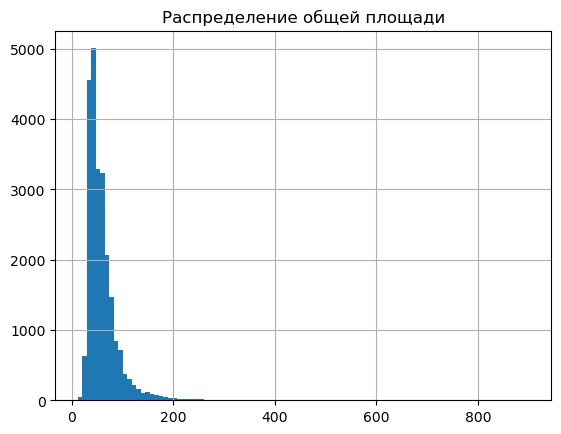

In [74]:
data['total_area'].hist(bins=100)
plt.title('Распределение общей площади')
plt.show()

По гистограмме видно, что квартиры площадью больше 200 практически не встречаются, а около 400 гистограмма сливается с нулем. Примем верхнюю границу в 200 квадратных метров. Это число кажется разумным: жилые помещения такой площади весьма редки и сделки с такими помещениями нужно рассматривать отдельно от массового сегмента. Если отбросить значения больше 200, много данных не потеряется.

In [76]:
data = data.loc[data['total_area'] < 200]

##### Жилая площадь

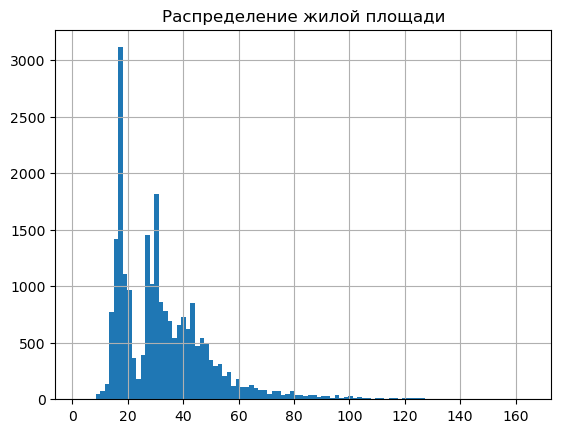

In [78]:
data['living_area'].hist(bins=100)
plt.title('Распределение жилой площади')
plt.show()

Распределение жилой площади похоже на распределение общей площади. Аналогично удалим значения выше 110.

In [80]:
data = data.loc[data['living_area'] < 110]

##### Площадь кухни

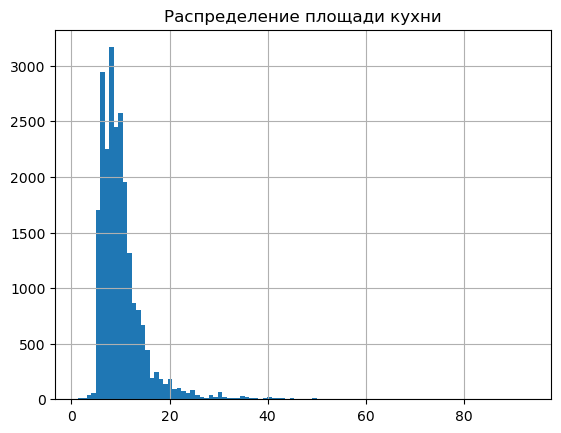

In [82]:
data['kitchen_area'].hist(bins=100)
plt.title('Распределение площади кухни')
plt.show()

По аналогии с общей площадью удалим значения выше 40. Так же обратим внимание, что в выборке есть значения меньше 4, явно записанные по ошибке: такое значение не объяснить погрешностью при измерениях или ошибкой.

In [84]:
data = data.loc[(data['kitchen_area'] > 4.5) & (data['kitchen_area'] < 40)]

##### Цена объекта

Цену объекта будем исследовать по цене за квадратный метр.

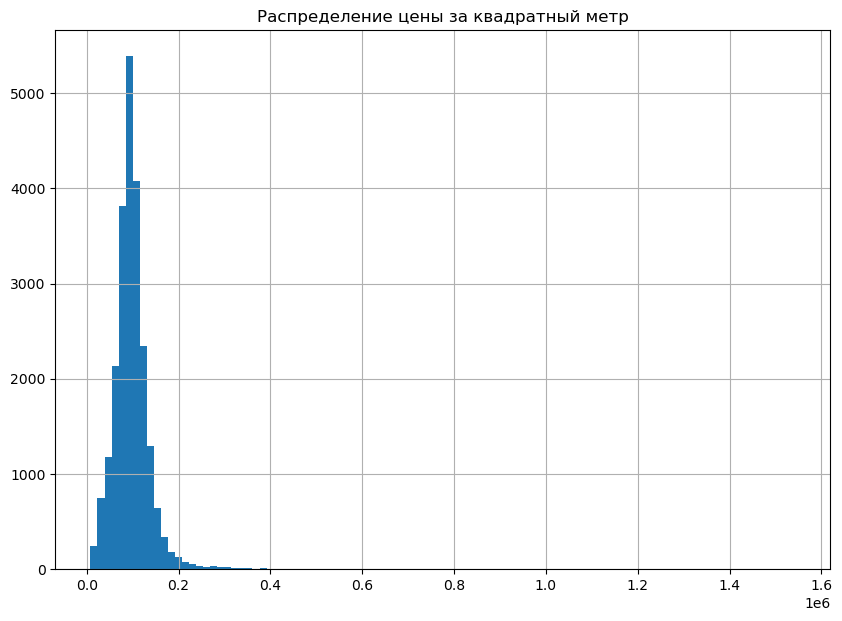

In [87]:
data['price_per_square_meter'].hist(bins=100, figsize=(10, 7))
plt.title('Распределение цены за квадратный метр')
plt.show()

На гистограмме мы видим, что значения выше 300000 почти не встречаются. Возможно это обладающие какими-то уникальными потребительскими свойствами либо ошибка, возникшая при сборе данных. Удалим эти значения.

In [89]:
data = data.loc[data['price_per_square_meter'] < 300000]

##### Количество комнат

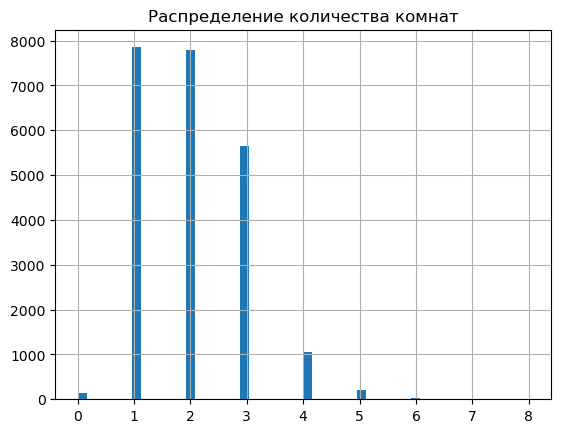

In [91]:
data['rooms'].hist(bins=50)
plt.title('Распределение количества комнат')
plt.show()

По гистограмме мы видим, что в данных практически нет 7-ми и 8-микомнатных квартир. Это вряд ли можно объяснить какой-то ошибкой или багом.

In [93]:
data = data.loc[data['rooms'] < 7]

##### Тип этажа квартиры

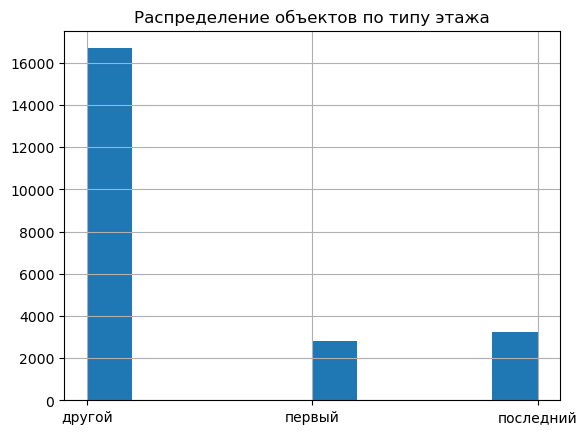

In [95]:
data['type_floors'].hist()
plt.title('Распределение объектов по типу этажа')
plt.show()

Вполне реалистичное распределение: "первый" примерно равен "последнему", число "других" этажей сильно превышает сумму первого и последнего.

##### Общее количество этажей в доме

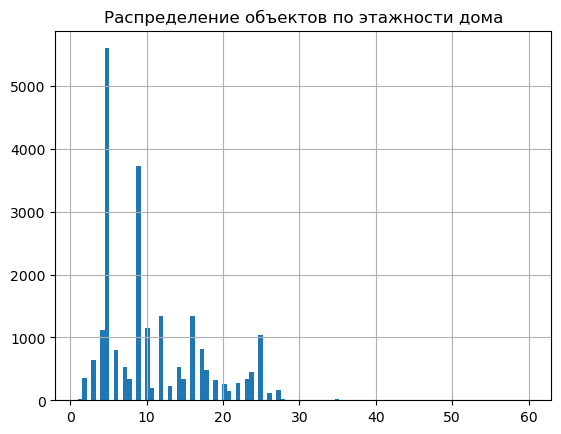

In [98]:
data['floors_total'].hist(bins=100)
plt.title('Распределение объектов по этажности дома')
plt.show()

На графике почти не видно помещений в домах выше 30 этажей. И это не удивительно: в Ленинградской области самое высокое здание имеет 29 этажей, а в СПб 37. Удалим данные с домами выше 30 этажей.

In [100]:
data = data.loc[data['floors_total'] < 30]

##### Высота потолков

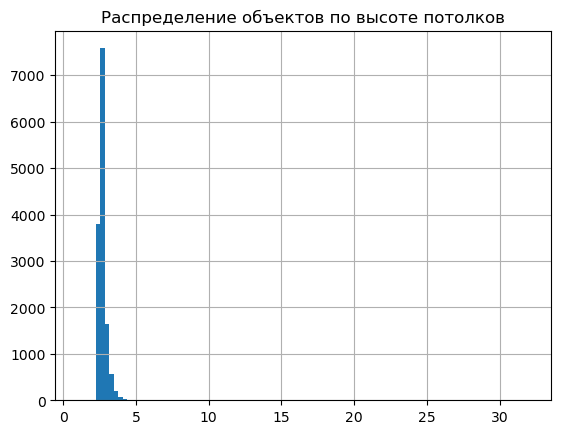

In [102]:
data['ceiling_height'].hist(bins=100)
plt.title('Распределение объектов по высоте потолков')
plt.show()

Обычно высота потолка в квартирах 2,4-5м. Но на гистограмме видим, что есть значения, сильно выбивающиеся из данного диапазона. Посмотрим помещения с аномально выскокими потолками.

In [104]:
data.loc[data['ceiling_height'] > 4].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,studio,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_square_meter,weekday_exposition,month_exposition,year_exposition,type_floors,city_centers_nearest_km
154,1,8200000,80.0,2018-11-06,3,4.15,3,44.2,2,False,...,344,1,838,38,102500.00,1,11,2018,другой,3
355,17,3600000,55.2,2018-07-12,2,25.00,5,32.0,2,False,...,<NA>,0,<NA>,259,65217.39,3,7,2018,другой,<NA>
1053,13,550000,29.0,2018-02-01,1,5.00,3,15.5,1,False,...,<NA>,0,<NA>,6,18965.52,3,2,2018,первый,<NA>
1129,20,6695000,36.9,2018-09-28,1,4.06,5,22.0,2,False,...,596,1,866,110,181436.31,4,9,2018,другой,3
2639,17,4850000,59.7,2017-11-18,3,4.19,5,46.3,4,False,...,460,0,503,60,81239.53,5,11,2017,другой,15
2802,7,14950000,50.0,2016-03-06,2,4.80,3,30.0,2,False,...,589,3,161,160,299000.00,6,3,2016,другой,2
2823,8,2700000,39.0,2018-02-01,1,4.50,6,18.3,6,False,...,<NA>,0,<NA>,<NA>,69230.77,3,2,2018,последний,<NA>
2843,15,11990000,104.0,2018-03-13,3,4.20,3,66.0,2,False,...,460,0,503,350,115288.46,1,3,2018,другой,4
2999,11,4450000,36.0,2017-12-12,1,4.19,5,18.0,1,False,...,1077,3,690,78,123611.11,1,12,2017,первый,4
3067,13,6600000,95.0,2018-09-08,2,4.50,7,45.0,7,False,...,<NA>,0,<NA>,96,69473.68,5,9,2018,последний,<NA>


В данной выборке есть помещения большой площади с высотой потолков 4-5м, что вполне возможно. Но в то же время есть квартиры небольшой площадью с неадекватно высокими потолками, вероятнее всего эти значения ошибочны. Избавиммся от этих значений.

In [106]:
data = data.drop(index=data.loc[(data['ceiling_height'] > 4) & (data['total_area'] < 100)].index)

Аналогично посмотрим квартиры с аномально низкими потолками

In [108]:
data.loc[data['ceiling_height'] < 2.4].head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,studio,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_square_meter,weekday_exposition,month_exposition,year_exposition,type_floors,city_centers_nearest_km
227,13,2200000,47.00,2018-01-12,3,2.34,5,28.00,1,False,...,<NA>,0,<NA>,45,46808.51,4,1,2018,первый,<NA>
552,11,2999000,33.50,2017-03-30,1,2.00,15,17.50,6,False,...,520,1,949,270,89522.39,3,3,2017,другой,12
1582,4,4100000,45.60,2016-01-13,2,2.30,9,28.40,8,False,...,489,1,525,329,89912.28,2,1,2016,другой,15
2572,4,2400000,62.00,2018-12-27,3,2.00,5,40.00,4,False,...,<NA>,0,<NA>,<NA>,38709.68,3,12,2018,другой,<NA>
4212,1,2120000,35.43,2017-12-18,1,2.00,18,16.60,9,False,...,<NA>,0,<NA>,36,59836.30,0,12,2017,другой,<NA>
5498,17,2200000,56.00,2018-04-02,2,2.30,5,45.00,1,False,...,<NA>,0,<NA>,55,39285.71,0,4,2018,первый,<NA>
5712,5,1500000,42.80,2017-08-14,2,1.20,2,27.50,1,False,...,<NA>,0,<NA>,248,35046.73,0,8,2017,первый,<NA>
5850,9,1650000,35.50,2018-05-29,1,2.00,5,17.15,5,False,...,<NA>,0,<NA>,100,46478.87,1,5,2018,последний,<NA>
11352,4,3300000,36.00,2017-06-18,1,2.00,17,15.20,12,False,...,<NA>,0,<NA>,53,91666.67,6,6,2017,другой,27
16446,6,12300000,88.30,2019-03-12,3,2.00,5,63.90,2,False,...,568,1,154,<NA>,139297.85,1,3,2019,другой,8


Мы видим значения даже меншьше 2 метров, записанные явно по ошибке. Но в то же время видим значения 2,34 м, которые могли быть получены при установке натяжных потолков и погрешности измерений. Таких значений всего 21, поэтому ими можно пренебречь.

In [110]:
data = data.drop(index=data.loc[data['ceiling_height'] < 2.4].index)

##### расстояние до центра города в метрах

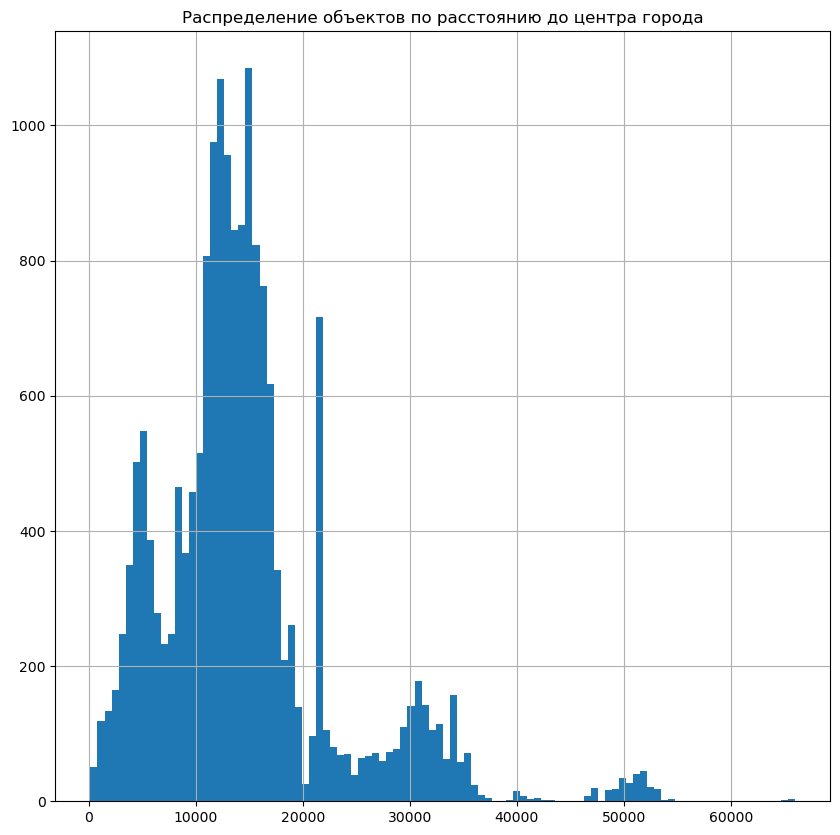

In [112]:
data['city_centers_nearest'].hist(bins=100, figsize=(10, 10))
plt.title('Распределение объектов по расстоянию до центра города')
plt.show()

In [113]:
data.loc[data['city_centers_nearest'] > 50000]['locality_name'].value_counts()

locality_name
Ломоносов      118
Кронштадт       36
Зеленогорск     23
Молодежное       5
Name: count, dtype: int64

Значения выше 50000 метров являются очень редкими. Но в то же время они не являются ошибочными. Удалив их, мы можем исказить данные по населенному пункту, в котором находится объект, поэтому я считаю, что данные целесообразно оставить как есть.

##### Расстояние до ближайшего парка

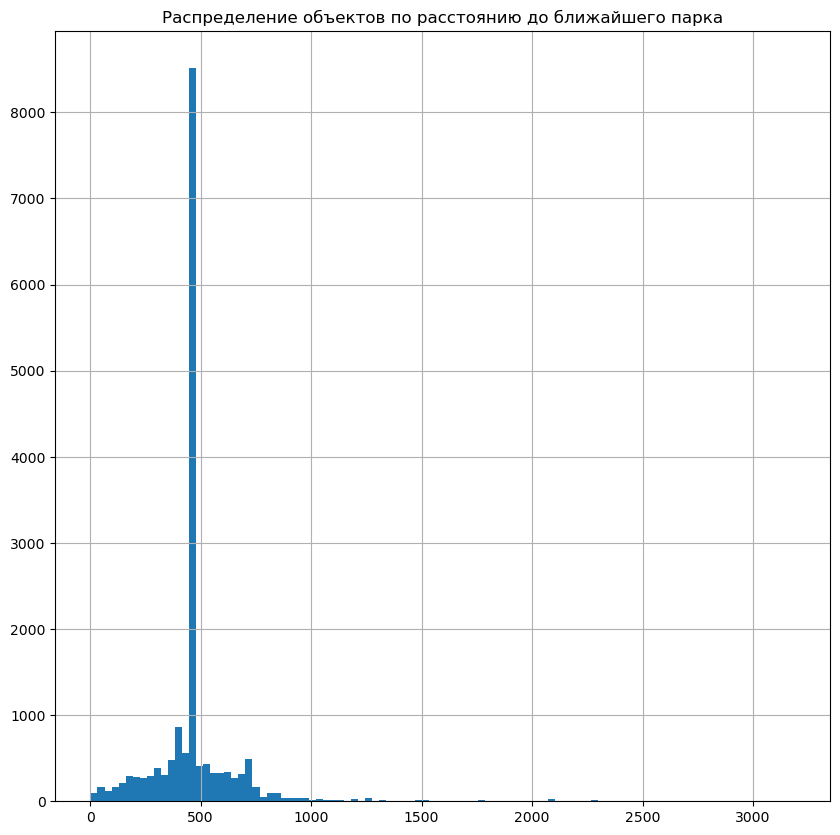

In [116]:
data['parks_nearest'].hist(bins=100, figsize=(10, 10))
plt.title('Распределение объектов по расстоянию до ближайшего парка')
plt.show()

Как видно, очень мало значений выше 1500 метров. Если отбросить значения выше 1500, много данных не потеряется. И наличие парка на таком расстоянии уже не должно оказывать сильное влияние на стоимость

In [118]:
data = data.loc[(data['parks_nearest'] < 1500) | (data['parks_nearest'].isna())]

#### Исследуем время продажи объекта

Построим гистограмму по столбцу `days_exposition`, определим среднее и медианное значения.

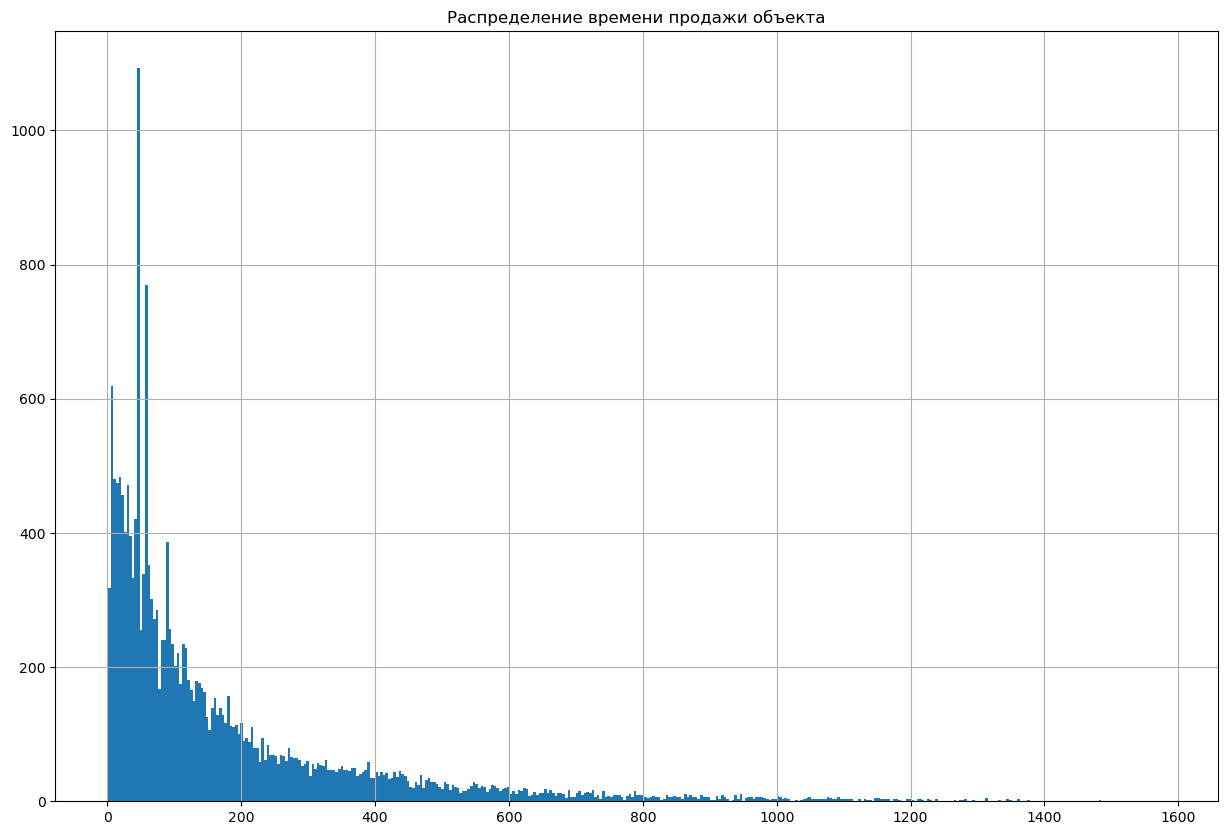

In [121]:
data['days_exposition'].hist(bins=400, figsize=(15, 10))
plt.title('Распределение времени продажи объекта')
plt.show()

Из гистограммы видно, что данные распределены очень неравномерно. Применим метод `describe()`:

In [123]:
data['days_exposition'].describe()

count       19499.0
mean     178.894866
std      216.988083
min             1.0
25%            45.0
50%            94.0
75%           228.5
max          1580.0
Name: days_exposition, dtype: Float64

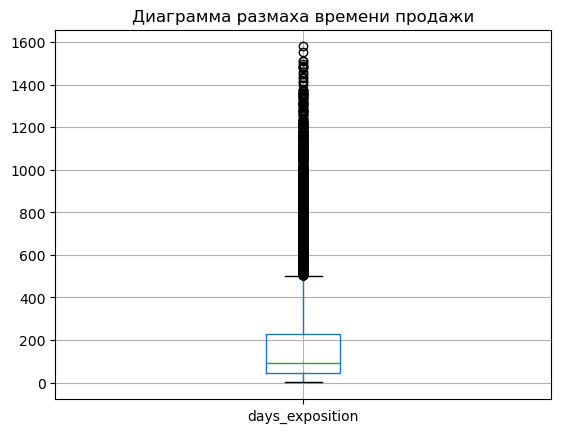

In [124]:
data.boxplot(column='days_exposition')
plt.title('Диаграмма размаха времени продажи')
plt.show()

Так же на гистограмме видны выбросы, изучим их подробнее:

In [126]:
data.groupby('days_exposition')['last_price'].count().sort_values(ascending=False).head(10)

days_exposition
45    852
60    522
7     224
30    202
4     164
90    162
3     151
5     143
14    137
20    135
Name: last_price, dtype: Int64

Как видно, медианное время продажи объекта составляет 94 дня и сильно отличается от среднего. 25% квартир продается за 45 дней, этот срок мы можем считать быстрой продажей. По построенной выше диаграмме размаха видно, что ориентировочная граница нормального размаха составляет 500 дней. Значения более 500 мы можем назвать необычайно долгими при том, что 75% продаж происходят за 228 дней. Так же видны выбросы в "округленных" числах (7, 30, 45, 60, 90 и так далее), что соответствует недели, месяцу, 1,5 месяцам, 2 месяцам, 3 месяцам и так далее. Возможно они образовались в связи с заполнением данных не в день продажи и был записан не точный день продажи объекта, а округленное значение.

#### Определим факторы, которые больше всего влияют на общую (полную) стоимость объекта

##### Изучим, как зависит стоимость объекта от общей площади, жилой площади и площади кухни

Создадим переменную `area_stat`, где для объекта каждой стоимости посчитаем среднее значение каждой из площадей

In [131]:
area_stat = data.pivot_table(index='last_price', values=['total_area', 'living_area', 'kitchen_area'])
area_stat['price'] = area_stat.index.astype(int)

Построим матрицу диаграмм рассеяния и таблицу коэффициентов корреляции.

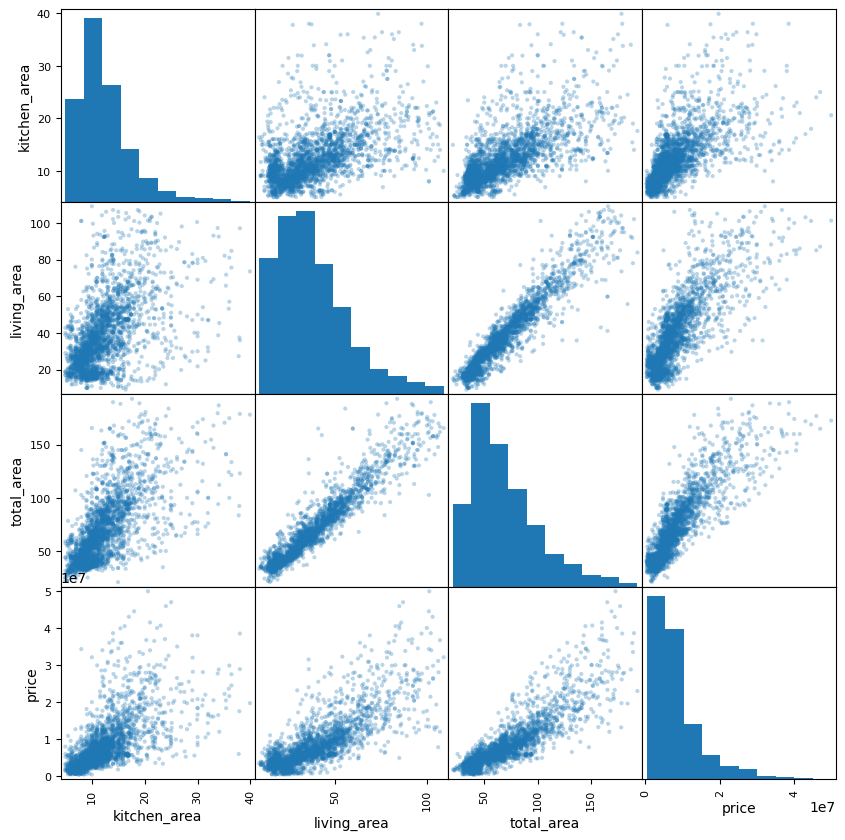

In [133]:
pd.plotting.scatter_matrix(area_stat, figsize=(10,10), alpha=0.3)
plt.show()

In [134]:
area_stat.corr()

,kitchen_area,living_area,total_area,price
kitchen_area,1.000000,0.517094,0.671296,0.646505
living_area,0.517094,1.000000,0.946392,0.791793
total_area,0.671296,0.946392,1.000000,0.864323
price,0.646505,0.791793,0.864323,1.000000


На графике и таблице корреляций видно, что все три вида площади коррелируют с ценой объекта, наиболее ярко зависимость выражена на площадях до 110 квадратных метров, возможно зависимость цены объектов с более высокой площадью зависит от площади уже нелинейно. На больших площадях зависимость сохраняется, но уже менее выраженно. Наиболее выражена зависимость цены и общей площади (коэффициент корреляции 0,86).

##### Изучим, как зависит стоимость объекта от количества комнат

Создадим переменную `rooms_stat`: сгруппируем исходный датафрейм по количеству комнат, посчитаем среднюю цену объекта и построим график зависимости стоимости от количества комнат.

In [138]:
rooms_stat = data.pivot_table(index='rooms', values=['last_price'])
rooms_stat['rooms'] = rooms_stat.index.astype(int)

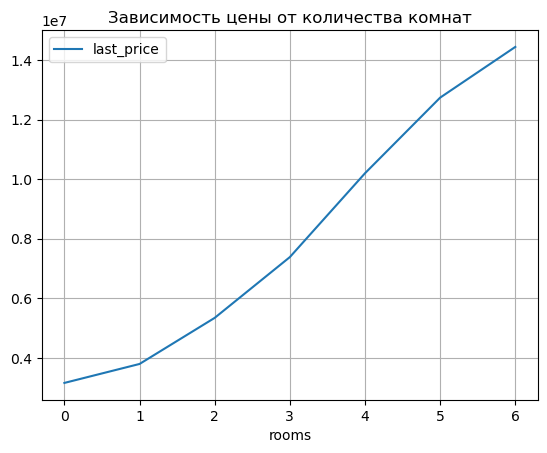

In [139]:
rooms_stat.plot(x='rooms', y='last_price', grid=True)
plt.title('Зависимость цены от количества комнат')
plt.show()

In [140]:
rooms_stat.corr()

,last_price,rooms
last_price,1.00000,0.98797
rooms,0.98797,1.00000


Мы видим почти полную линейную зависимость цены от количества комнат, коэффициент корреляции почти равен 1.

##### Изучим, как зависит стоимость объекта от этажа, на котором расположена квартира

Создадим переменную `floor_stat`: сгруппируем исходный датафрейм по типу этажа, посчитаем среднюю цену объекта и построим график зависимости стоимости от этажа объекта.

In [144]:
floor_stat = data.pivot_table(index='type_floors', values='last_price')

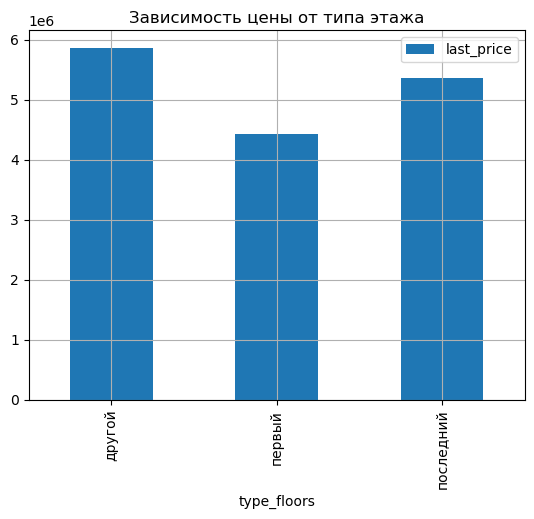

In [145]:
floor_stat.plot(kind='bar', grid=True)
plt.title('Зависимость цены от типа этажа')
plt.show()

Дешевле всего продаются объекты на первых этажах. Цена объектов, находящихся на последнем этаже, находится примерно посередине между ценами на первом и других этажах.

##### Изучим, как зависит стоимость объекта от даты размещения

###### День недели

Создадим переменную `weekday_stat`: сгруппируем исходный датафрейм по дням недели, посчитаем среднюю цену объекта и построим график зависимости стоимости от дня недели, в который было размещено объявление.

In [150]:
weekday_stat = data.pivot_table(index='weekday_exposition', values='last_price')

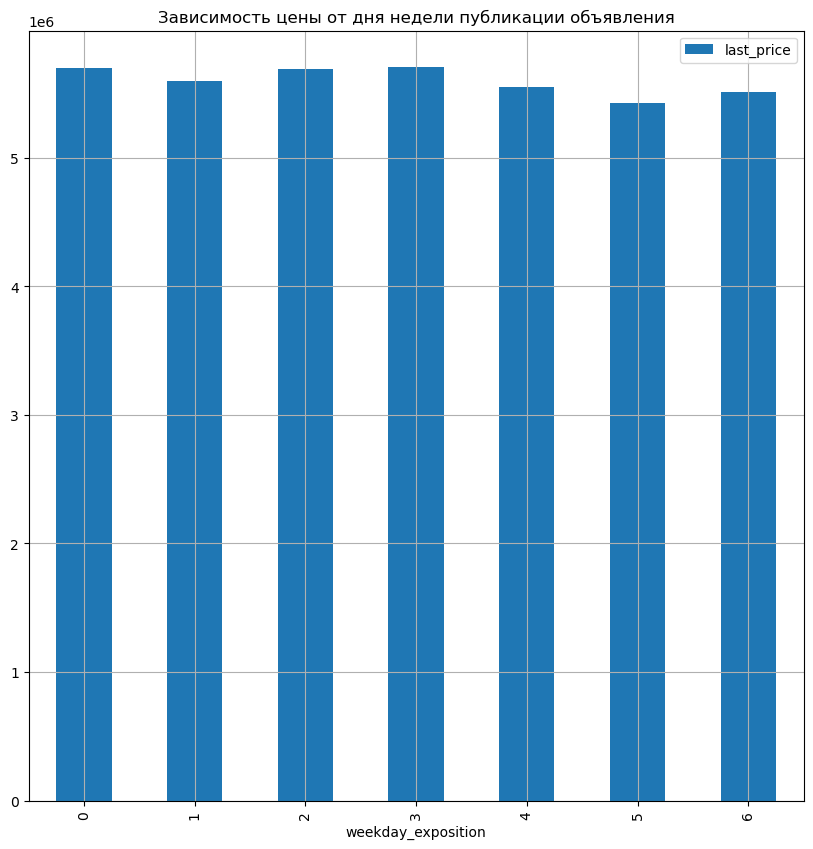

In [151]:
weekday_stat.plot(kind='bar', figsize=(10, 10), grid=True)
plt.title('Зависимость цены от дня недели публикации объявления')
plt.show()

In [152]:
weekday_stat['last_price'].describe().apply("{0:.0f}".format)

count          7
mean     5595678
std       106348
min      5427281
25%      5530299
50%      5594064
75%      5693080
max      5701640
Name: last_price, dtype: object

Как видно, зависимости стоимости от дня недели публикации не прослеживается, максимальное и минимальное начения отличаются всего на 5%.

###### Месяц

Создадим переменную `month_stat`: сгруппируем исходный датафрейм по дням недели, посчитаем среднюю цену объекта и построим график зависимости стоимости от месяца публикации.

In [156]:
month_stat = data.pivot_table(index='month_exposition', values='last_price')

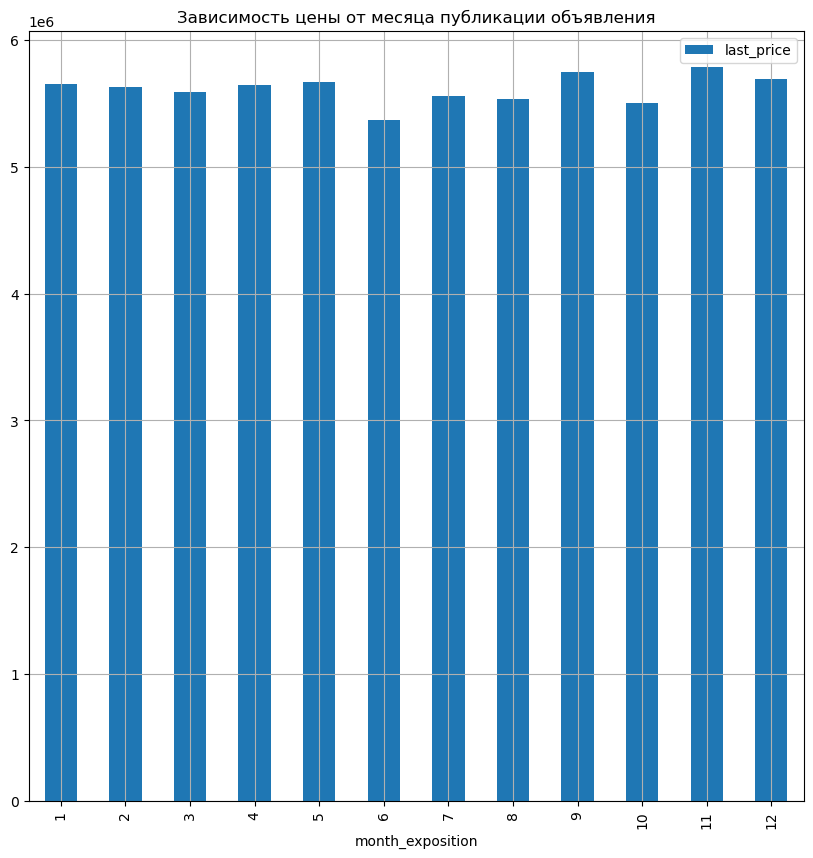

In [157]:
month_stat.plot(kind='bar', figsize=(10, 10), grid=True)
plt.title('Зависимость цены от месяца публикации объявления')
plt.show()

Видно, что по цена продажи по месяцам примерно одинакова, минимум приходится на летние месяцы. Возможно летнее снижение можно объяснить сезоном отпусков.

###### Год

Создадим переменную `year_stat`: сгруппируем исходный датафрейм по дням недели, посчитаем среднюю цену объекта и построим график зависимости стоимости от года публикации.

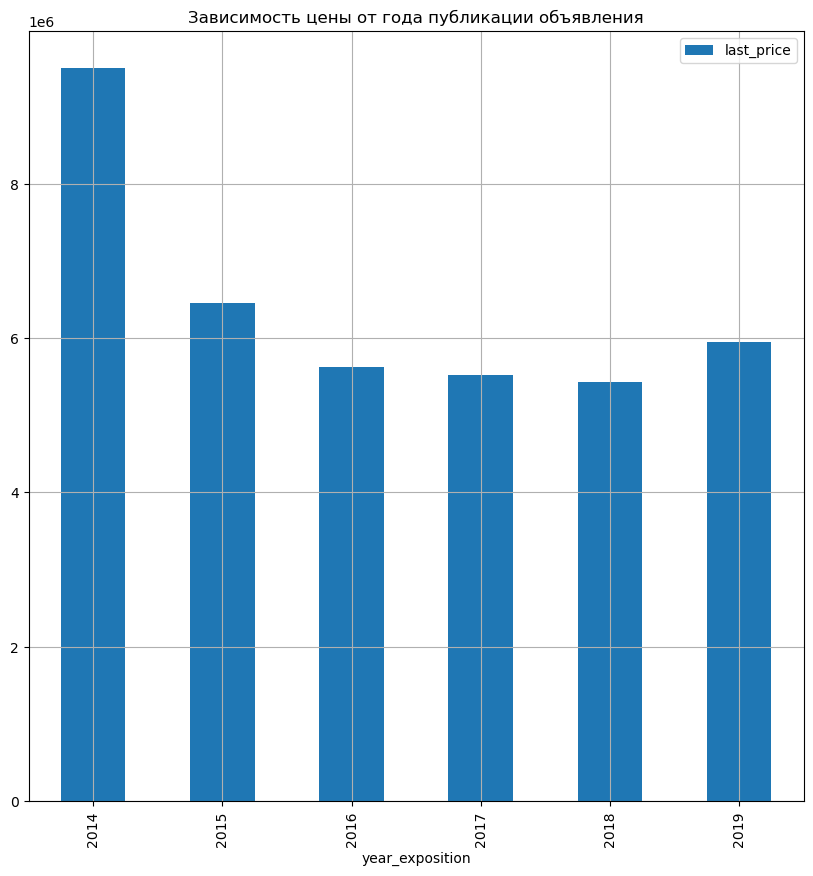

In [161]:
year_stat = data.pivot_table(index='year_exposition', values='last_price')
year_stat.plot(kind='bar', figsize=(10, 10), grid=True)
plt.title('Зависимость цены от года публикации объявления')
plt.show()

На гистограмме мы видим сильно выделяющийся максимум в 2014 году, снижение до 2018 года и небольшой рост в последующие годы. Возможно это можно объяснить экономической ситуацией в стране: после кризиса 2014 года люди пытались сохранить свои сбережения и ажиатажно покупали недвижимость. Далее после спада ажиотажа цены пошли вниз и начали расти после нормализации экономики в 2018 году.

#### Изучим среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений

Составим сводную таблицу, в которой будет храниться информация о ценах за квадратный метр и количестве объявлений по каждому населенному пункту.

In [165]:
location_stat = data.pivot_table(index='locality_name', values='price_per_square_meter', aggfunc=['mean', 'count'])

Отсортируем таблицу по числу объявлений:

In [167]:
location_stat.sort_values(by=('count', 'price_per_square_meter'), ascending=False, inplace=True)

Оставим в таблице 10 локаций с наибольшим числом объявлений и построим график распределения цены за квадратный метр в зависимости от локации:

In [169]:
location_stat = location_stat.head(10).sort_values(by=('mean', 'price_per_square_meter'), ascending=False)

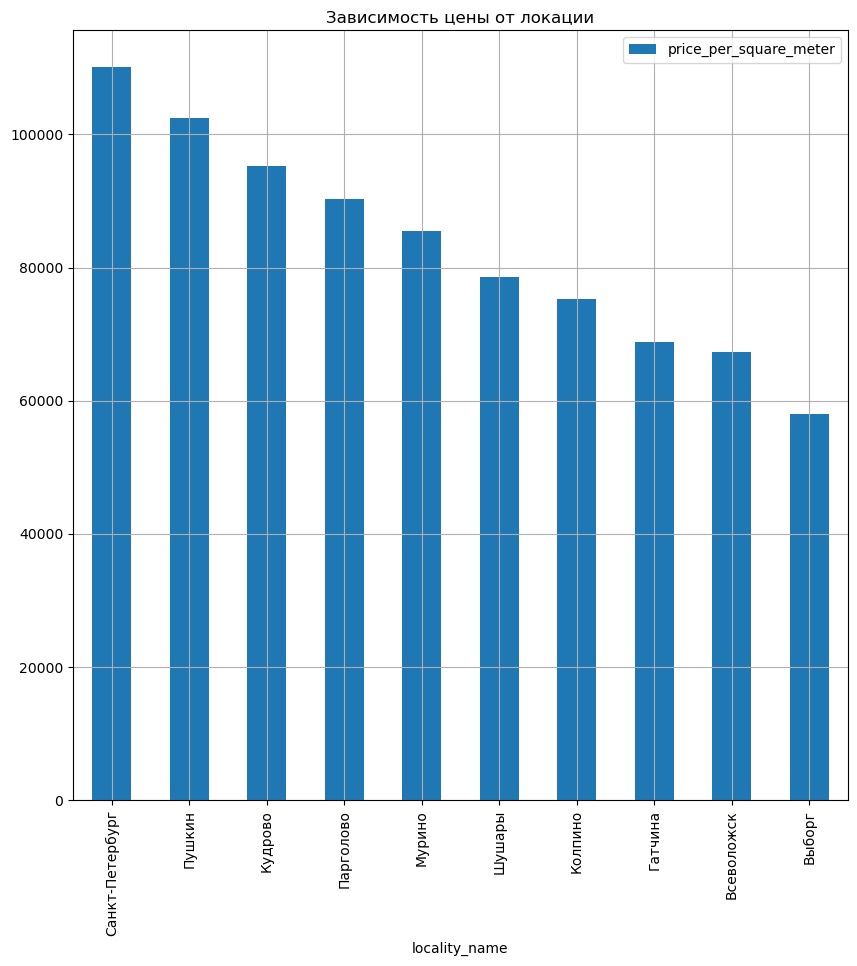

In [170]:
location_stat['mean'].plot(kind='bar', figsize=(10, 10), grid=True)
plt.title('Зависимость цены от локации')
plt.show()

Ожидаемо с отрывом на первом месте находится Санкт-Петербург с ценой более 110 тысяч за квадратный метр, за ним идет Пушкин с ценой около 102 тысяч за квадрат. Самые дешевые же квартиры в Выборге с ценой 58 тысяч за квадрат.

#### Изучим квартиры в Санкт-Петербурге и вычислим их среднюю стоимость на разном удалении от центра

Выберем из датафрейма объявления из Санкт-Петербурга и сгруппируем их по расстоянию от центра города:

In [174]:
spb = data.loc[data['locality_name'] == 'Санкт-Петербург'].pivot_table(index='city_centers_nearest_km', values='last_price', aggfunc=['mean', 'count'])
spb['range'] = spb.index.astype(int)

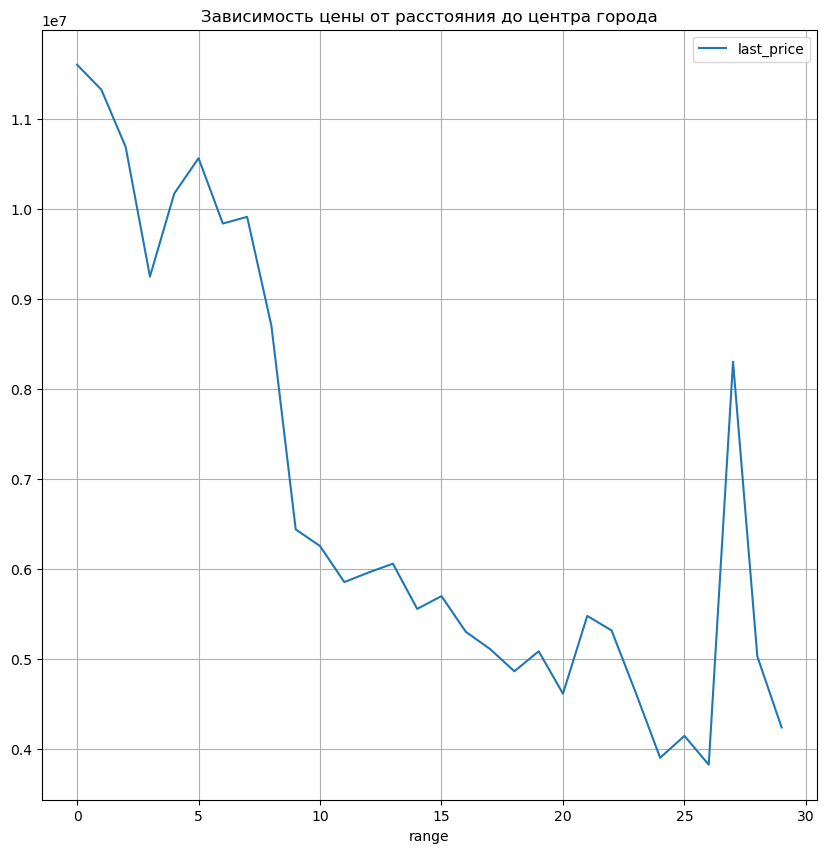

In [175]:
spb.plot(x='range', y='mean', figsize=(10, 10), grid=True)
plt.title('Зависимость цены от расстояния до центра города')
plt.show()

In [176]:
spb.corr()

,,mean,count,range
,,last_price,last_price,
mean,last_price,1.000000,-0.021686,-0.837790
count,last_price,-0.021686,1.000000,-0.305503
range,,-0.837790,-0.305503,1.000000


Цена за объект и расстояние до центра имеют весьма сильную обратную зависимость (коэффициент корреляции -0,84). Стоит отметить, что после 8 километра скорость падения снижается. Это говорит о меньшей зависимости стоимости от расстояния до центра у объектов начиная с восьмого километра. Так же обратим внимание на скачок цен на двадцать седьмом километре. Возможно это объясняется малым числом объявлений на таком расстоянии:

In [178]:
spb.tail(3)

,mean,count,range
,last_price,last_price,
city_centers_nearest_km,,,
27,8300000.0,2,27
28,5026428.571429,7,28
29,4236666.666667,6,29


Действительно, таких объектов уже немного, и они могли исказить данные. Таким образом,делаем вывод, что расстояние от центра города имеет достаточно сильную обратную зависимость с ценой объекта.

**В данном пункте был произведен исследовательский анализ данных:**
- Удалены аномальные значения в столбцах `total_area`, `living_area`, `kitchen_area`, `price_per_square_meter`, `rooms`, `floors_total`, `ceiling_height`, `city_centers_nearest`, `parks_nearest`
- Изучено, как быстро продавались квартиры: 25% продавалось быстрее, чем за 49 дней, что можно считать быстрой продажей, 75% продавалось за 229 дней. По диаграмме распределения была выявлена граница необычно долгих продаж: 500 дней
- Изучена зависимость стоимости объекта от: общей площади, жилой площади, площади кухни, количества комнат, этажа, на котором расположена квартира (первый, последний, другой), даты размещения (день недели, месяц, год)
- Выделены населённые пункты с самой высокой и низкой стоимостью квадратного метра
- выделены квартиры в Санкт-Петербурге и вычислена средняя стоимость на разном удалении от центра

### Напишите общий вывод

Целью проекта было определение фокторов, влияющих на цену объекта. В ходе выполнения была заполнена большая часть пропусков, однако, полностью заполнить их не представляется возможным, но на достоверность данных сильное влияние это не оказало. Были исправлены неявные дубликаты в столбце `locality_name`. Добавлены столбцы с ценой квадратного метра, дня, месяца и года публикации объявления, расстояние до центра города в километрах, произведена категоризация типа этажа. Удалены аномальные значения в ряде столбцов.

В ходе исследования получившегося датафрейма получены следующие выводы:
- 25% квартир продается за 45 дней, этот срок мы можем считать быстрой продажей. Значения более 500 мы можем назвать необычайно долгими при том, что 75% продаж происходят за 228 дней
- Среди параметров общая/жилая/площадь кухни бОльшей зависимостью с общей стоимостью обладает общая площадь (r=0,86)
- Стоимость объекта сильно зависит от количества комнат (r=0,987)
- Дешевле всего продаются объекты на первых этажах. Цена объектов, находящихся на последнем этаже, находится примерно посередине между ценами на первом и других этажах
- Отсутствует зависимость стоимости от дня недели публикации
- Цена продажи по месяцам примерно одинакова, минимум приходится на летние месяцы
- Сильно выделяющийся максимум цен в 2014 году, снижение до 2018 года и небольшой рост в последующие годы
- На первом месте по ценам за квадратный метр находится Санкт-Петербург с ценой более 110 тысяч за квадратный метр, за ним идет Пушкин с ценой около 102 тысяч за квадрат. Самые дешевые же квартиры в Выборге с ценой 58 тысяч за квадрат
- Цена за объект и расстояние до центра имеют весьма сильную обратную зависимость (r=-0,84). Стоит отметить, что после 8 километра скорость падения снижается. Это говорит о меньшей зависимости стоимости от расстояния до центра у объектов начиная с восьмого километра